In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
print("Shape:", df.shape)
df.head()

Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [7]:
import warnings
warnings.filterwarnings('ignore')

In [8]:
# Cell 2 - Data Overview
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())
print("\nBasic Stats:")
df[['MonthlyIncome', 'PercentSalaryHike', 'JobLevel', 'YearsSinceLastPromotion']].describe()

Shape: (1470, 32)

Column Names:
 ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Missing Values:
 Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvemen

,MonthlyIncome,PercentSalaryHike,JobLevel,YearsSinceLastPromotion
count,1470.000000,1470.000000,1470.000000,1470.000000
mean,6502.931293,15.209524,2.063946,2.187755
std,4707.956783,3.659938,1.106940,3.222430
min,1009.000000,11.000000,1.000000,0.000000
25%,2911.000000,12.000000,1.000000,0.000000
50%,4919.000000,14.000000,2.000000,1.000000
75%,8379.000000,18.000000,3.000000,3.000000
max,19999.000000,25.000000,5.000000,15.000000


In [3]:
# Cell 3 - Drop useless columns
df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours'], inplace=True)
print("Remaining columns:", df.shape[1])

Remaining columns: 32


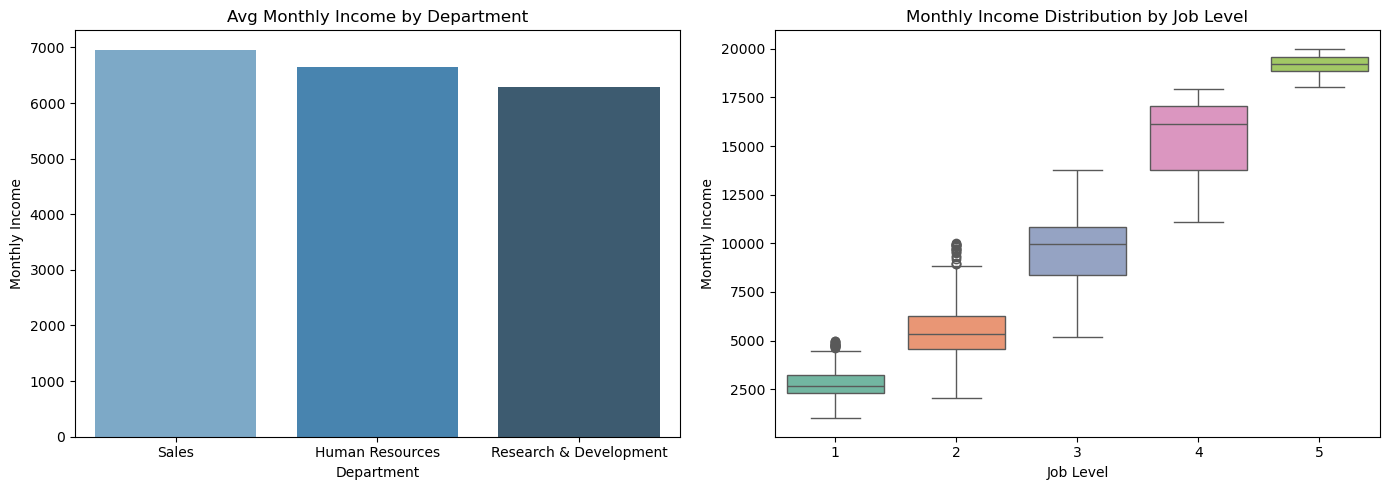

In [9]:
# Cell 4 - Salary by Department & Job Level
plt.figure(figsize=(14, 5))

# Plot 1 - Avg Salary by Department
plt.subplot(1, 2, 1)
dept_salary = df.groupby('Department')['MonthlyIncome'].mean().sort_values(ascending=False)
sns.barplot(x=dept_salary.index, y=dept_salary.values, palette='Blues_d')
plt.title('Avg Monthly Income by Department')
plt.ylabel('Monthly Income')
plt.xlabel('Department')

# Plot 2 - Salary by Job Level
plt.subplot(1, 2, 2)
sns.boxplot(x='JobLevel', y='MonthlyIncome', data=df, palette='Set2')
plt.title('Monthly Income Distribution by Job Level')
plt.ylabel('Monthly Income')
plt.xlabel('Job Level')

plt.tight_layout()
plt.savefig('salary_by_dept_joblevel.png', dpi=150)
plt.show()

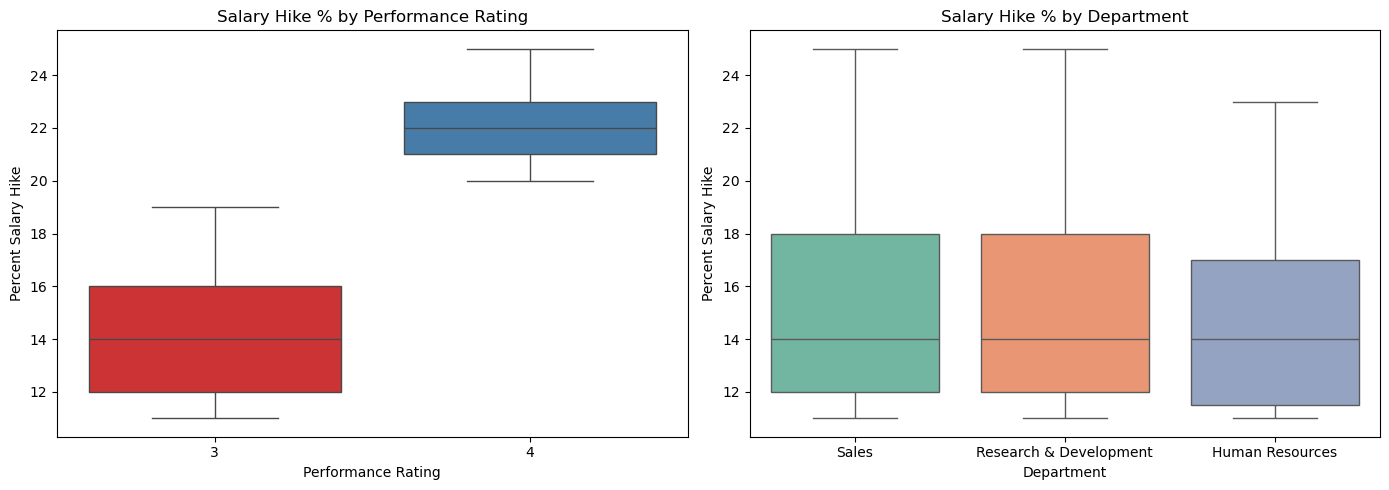

In [10]:
# Cell 5 - Salary Hike vs Performance Rating
plt.figure(figsize=(14, 5))

# Plot 1 - Hike % by Performance Rating
plt.subplot(1, 2, 1)
sns.boxplot(x='PerformanceRating', y='PercentSalaryHike', data=df, palette='Set1')
plt.title('Salary Hike % by Performance Rating')
plt.xlabel('Performance Rating')
plt.ylabel('Percent Salary Hike')

# Plot 2 - Hike % by Department
plt.subplot(1, 2, 2)
sns.boxplot(x='Department', y='PercentSalaryHike', data=df, palette='Set2')
plt.title('Salary Hike % by Department')
plt.xlabel('Department')
plt.ylabel('Percent Salary Hike')

plt.tight_layout()
plt.savefig('salary_hike_analysis.png', dpi=150)
plt.show()

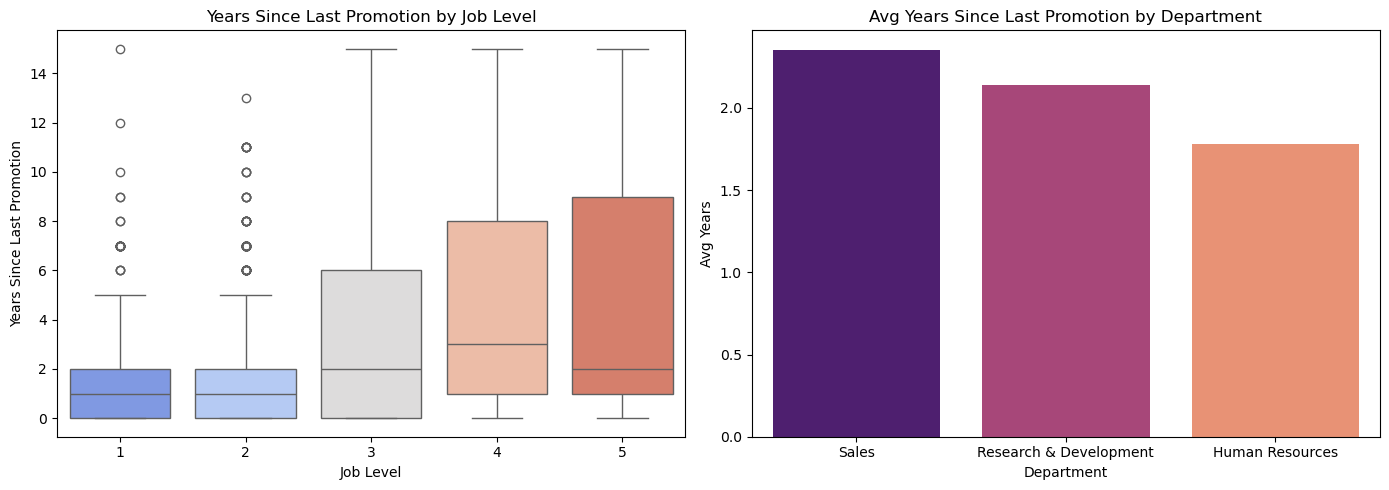

In [11]:
# Cell 6 - Promotion Analysis
plt.figure(figsize=(14, 5))

# Plot 1 - Years Since Last Promotion by Job Level
plt.subplot(1, 2, 1)
sns.boxplot(x='JobLevel', y='YearsSinceLastPromotion', data=df, palette='coolwarm')
plt.title('Years Since Last Promotion by Job Level')
plt.xlabel('Job Level')
plt.ylabel('Years Since Last Promotion')

# Plot 2 - Promotion gap by Department
plt.subplot(1, 2, 2)
dept_promo = df.groupby('Department')['YearsSinceLastPromotion'].mean().sort_values(ascending=False)
sns.barplot(x=dept_promo.index, y=dept_promo.values, palette='magma')
plt.title('Avg Years Since Last Promotion by Department')
plt.xlabel('Department')
plt.ylabel('Avg Years')

plt.tight_layout()
plt.savefig('promotion_analysis.png', dpi=150)
plt.show()

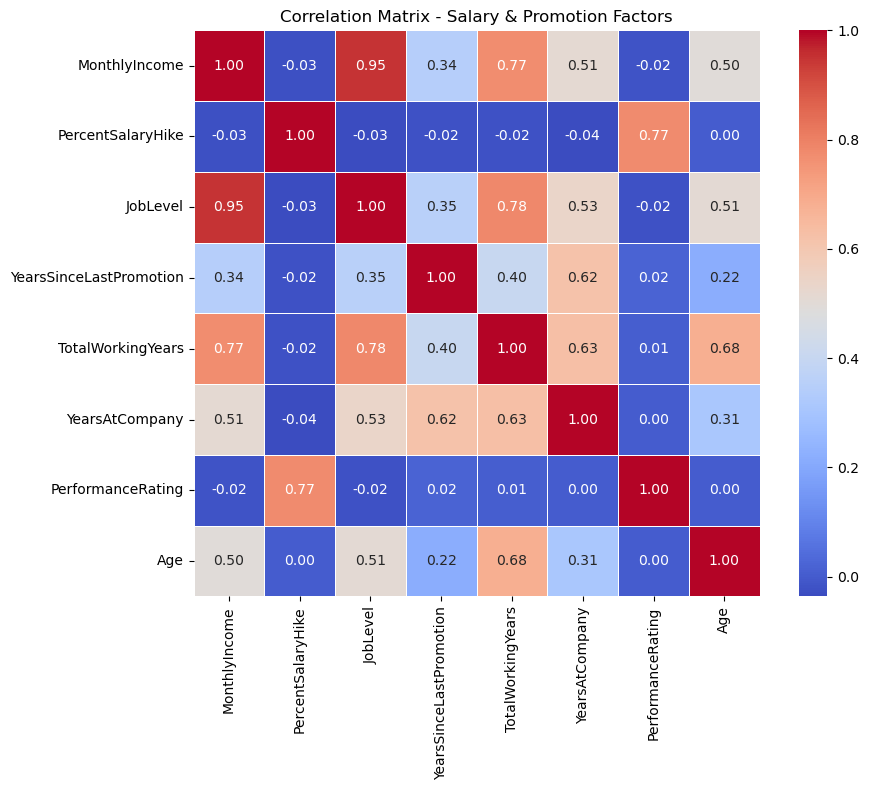

In [12]:
# Cell 7 - Correlation Heatmap
plt.figure(figsize=(10, 8))

cols = ['MonthlyIncome', 'PercentSalaryHike', 'JobLevel', 
        'YearsSinceLastPromotion', 'TotalWorkingYears', 
        'YearsAtCompany', 'PerformanceRating', 'Age']

corr = df[cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix - Salary & Promotion Factors')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

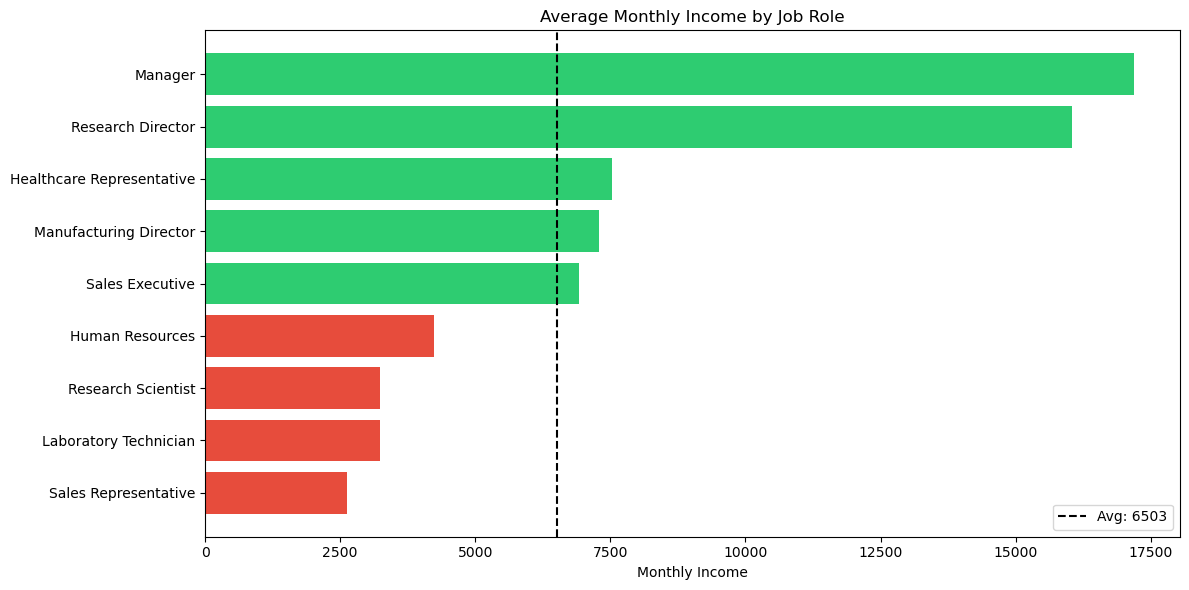

In [13]:
# Cell 8 - Avg Salary by Job Role
plt.figure(figsize=(12, 6))

role_salary = df.groupby('JobRole')['MonthlyIncome'].mean().sort_values(ascending=True)
colors = ['#2ecc71' if v > df['MonthlyIncome'].mean() else '#e74c3c' for v in role_salary.values]

plt.barh(role_salary.index, role_salary.values, color=colors)
plt.axvline(df['MonthlyIncome'].mean(), color='black', linestyle='--', label=f'Avg: {df["MonthlyIncome"].mean():.0f}')
plt.title('Average Monthly Income by Job Role')
plt.xlabel('Monthly Income')
plt.legend()
plt.tight_layout()
plt.savefig('salary_by_jobrole.png', dpi=150)
plt.show()

In [14]:
# Cell 9 - Summary Insights Table
summary = df.groupby('JobRole').agg(
    Avg_Salary=('MonthlyIncome', 'mean'),
    Avg_Hike=('PercentSalaryHike', 'mean'),
    Avg_Years_Since_Promotion=('YearsSinceLastPromotion', 'mean'),
    Employee_Count=('JobRole', 'count')
).round(2).sort_values('Avg_Salary', ascending=False)

summary

,Avg_Salary,Avg_Hike,Avg_Years_Since_Promotion,Employee_Count
JobRole,,,,
Manager,17181.68,15.14,4.83,102
Research Director,16033.55,14.95,3.19,80
Healthcare Representative,7528.76,15.45,2.97,131
Manufacturing Director,7295.14,15.59,2.12,145
Sales Executive,6924.28,14.89,2.48,326
Human Resources,4235.75,14.81,1.27,52
Research Scientist,3239.97,15.45,1.51,292
Laboratory Technician,3237.17,15.05,1.42,259
Sales Representative,2626.00,15.67,1.06,83


In [15]:
# Cell 10 - Install Dash
import subprocess
subprocess.run(['pip', 'install', 'dash', 'dash-bootstrap-components'], capture_output=True)
print("Done")

Done


In [16]:
# Cell 11 - Create dashboard file
import os
os.makedirs('dashboard', exist_ok=True)

code = '''
import pandas as pd
import plotly.express as px
import dash
from dash import dcc, html
import dash_bootstrap_components as dbc

df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours'], inplace=True)

app = dash.Dash(__name__, external_stylesheets=[dbc.themes.DARKLY])

# Charts
fig1 = px.box(df, x='JobLevel', y='MonthlyIncome', color='JobLevel',
              title='Monthly Income by Job Level')

fig2 = px.box(df, x='PerformanceRating', y='PercentSalaryHike', color='PerformanceRating',
              title='Salary Hike % by Performance Rating')

role_salary = df.groupby('JobRole')['MonthlyIncome'].mean().reset_index().sort_values('MonthlyIncome')
fig3 = px.bar(role_salary, x='MonthlyIncome', y='JobRole', orientation='h',
              title='Avg Salary by Job Role', color='MonthlyIncome', color_continuous_scale='Viridis')

fig4 = px.box(df, x='JobLevel', y='YearsSinceLastPromotion', color='JobLevel',
              title='Years Since Last Promotion by Job Level')

dept_salary = df.groupby('Department')['MonthlyIncome'].mean().reset_index()
fig5 = px.bar(dept_salary, x='Department', y='MonthlyIncome',
              title='Avg Salary by Department', color='Department')

app.layout = dbc.Container([
    html.H1("HR Salary & Promotion Analysis Dashboard", 
            className="text-center my-4 text-warning"),
    html.P("IBM HR Analytics Dataset | 1,470 Employees", 
           className="text-center text-muted mb-4"),
    
    dbc.Row([
        dbc.Col(dcc.Graph(figure=fig1), md=6),
        dbc.Col(dcc.Graph(figure=fig2), md=6),
    ]),
    dbc.Row([
        dbc.Col(dcc.Graph(figure=fig3), md=8),
        dbc.Col(dcc.Graph(figure=fig5), md=4),
    ]),
    dbc.Row([
        dbc.Col(dcc.Graph(figure=fig4), md=12),
    ]),
], fluid=True)

if __name__ == "__main__":
    app.run(debug=True, port=8050)
'''

with open('dashboard/app.py', 'w') as f:
    f.write(code)

print("app.py created successfully")

app.py created successfully


In [17]:
# Cell 12 - Run Dashboard
import subprocess
import os

os.chdir('dashboard')
subprocess.Popen(['python', 'app.py'])
print("Dashboard starting at http://localhost:8050")

Dashboard starting at http://localhost:8050


In [18]:
# Cell 13 - Create .gitignore
import os
os.chdir('..')  # back to hr-salary-promotion-analysis folder

gitignore = """
__pycache__/
*.pyc
.ipynb_checkpoints/
venv/
*.png
"""

with open('.gitignore', 'w') as f:
    f.write(gitignore)
print("Done")

Done
